# MIMII Baseline — Autoencoder on Log-Mel Spectrograms

## Core idea

We train a **fully-connected autoencoder** on normal sounds only.  
At inference time, a normal clip passes through the bottleneck cleanly → low reconstruction error.  
An anomalous clip does not match the learned distribution → high reconstruction error.  
The reconstruction error is therefore our **anomaly score**.

```
normal clip  →  autoencoder  →  low MSE   → not flagged
abnormal clip →  autoencoder  →  high MSE  → flagged as anomaly
```

This approach is **unsupervised at train time** — no anomaly labels are used during training.  
Labels are only used at evaluation time to compute AUC-ROC.

## Architecture choice

Rather than feeding the entire 10-second spectrogram at once (which would require a large model), we use a **sliding-window** approach:  
each clip is broken into short overlapping *frame sequences* (5 consecutive mel frames = ~160 ms),  
each sequence is flattened into a 1-D vector and passed through the autoencoder independently.  
The **clip-level anomaly score** is the mean reconstruction error over all its frame sequences.

This is the approach used in the official DCASE 2020 Task 2 baseline paper.

In [1]:
# ── imports ───────────────────────────────────────────────────────────────────
import random
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1 — Configuration

All tunable parameters live in one place so the notebook is easy to re-run with different settings.

In [2]:
# ── audio ─────────────────────────────────────────────────────────────────────
DATA_ROOT   = Path('fan')
MACHINE_IDS = ['id_00', 'id_02', 'id_04', 'id_06']
SR          = 16_000
CHANNEL     = 0

# ── spectrogram ───────────────────────────────────────────────────────────────
N_FFT       = 1024
HOP_LEN     = 512
N_MELS      = 64

# ── sliding window ────────────────────────────────────────────────────────────
# Each training sample is N_FRAMES consecutive mel frames flattened to a vector.
# With HOP_LEN=512 @ 16kHz, one frame ≈ 32 ms → 5 frames ≈ 160 ms of context.
N_FRAMES    = 5
INPUT_DIM   = N_MELS * N_FRAMES   # 320

# ── training ──────────────────────────────────────────────────────────────────
EPOCHS      = 50
BATCH_SIZE  = 512
LR          = 1e-3
VAL_FRAC    = 0.1     # fraction of normal files held out for validation

print(f'Input vector size: {INPUT_DIM}')

Input vector size: 320


## 2 — Data manifest & splits

We re-use the same manifest pattern from the EDA notebook.  
For each machine ID, the split is:

- **Train** — 90% of normal files → used to fit the autoencoder
- **Val** — 10% of normal files → monitors training loss, never seen by the model during weight updates
- **Test** — all abnormal files + val-normal files → compute AUC-ROC against ground-truth labels

In [3]:
records = []
for machine_id in MACHINE_IDS:
    for label in ('normal', 'abnormal'):
        for wav in sorted((DATA_ROOT / machine_id / label).glob('*.wav')):
            records.append({'machine_id': machine_id, 'label': label, 'path': wav})

manifest = pd.DataFrame(records)
manifest['is_anomaly'] = (manifest['label'] == 'abnormal').astype(int)

# Assign train / val / test splits per machine ID
splits = []
for machine_id in MACHINE_IDS:
    normal = manifest[(manifest['machine_id'] == machine_id) & (manifest['label'] == 'normal')]
    abnormal = manifest[(manifest['machine_id'] == machine_id) & (manifest['label'] == 'abnormal')]

    train_idx, val_idx = train_test_split(normal.index, test_size=VAL_FRAC, random_state=SEED)

    manifest.loc[train_idx, 'split'] = 'train'
    manifest.loc[val_idx,   'split'] = 'val'
    manifest.loc[abnormal.index, 'split'] = 'test'

print(manifest.groupby(['machine_id', 'split']).size().unstack(fill_value=0)[['train', 'val', 'test']])

split       train  val  test
machine_id                  
id_00         909  102   407
id_02         914  102   359
id_04         929  104   348
id_06         913  102   361


## 3 — Feature extraction

We extract a **log-mel spectrogram** from each clip, then slice it into overlapping frame sequences.  

```
WAV file (160 000 samples)
  → STFT → mel filterbank → log → spectrogram  shape: (64, 313)
  → sliding window of width 5, stride 1        shape: (309, 320)
  → each row is one training example
```

We normalise each spectrogram to zero mean and unit variance using statistics computed from the training set only — this prevents information about the test set leaking into the normalisation.

In [4]:
def load_mono(path):
    audio, _ = sf.read(path, dtype='float32')
    return audio[:, CHANNEL] if audio.ndim == 2 else audio

def wav_to_logmel(path):
    """Return log-mel spectrogram of shape (N_MELS, T)."""
    y = load_mono(path)
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT,
                                        hop_length=HOP_LEN, n_mels=N_MELS)
    return librosa.power_to_db(S, ref=np.max).astype(np.float32)

def spectrogram_to_frames(spec, n_frames=N_FRAMES):
    """Slide a window of width n_frames over the time axis.
    Input: (N_MELS, T)  →  Output: (T - n_frames + 1, N_MELS * n_frames)
    """
    T = spec.shape[1]
    frames = np.stack(
        [spec[:, t:t + n_frames].flatten() for t in range(T - n_frames + 1)]
    )  # (T - n_frames + 1, N_MELS * n_frames)
    return frames

# ── compute training-set statistics for normalisation ─────────────────────────
print('Computing normalisation statistics from training files...')
train_paths = manifest[manifest['split'] == 'train']['path'].tolist()

# Two-pass: collect all frames to compute global mean & std
all_frames = []
for p in tqdm(train_paths):   # use a 200-file subset for speed; increase if desired
    all_frames.append(spectrogram_to_frames(wav_to_logmel(p)))

all_frames = np.concatenate(all_frames, axis=0)  # (N_total_frames, INPUT_DIM)
NORM_MEAN = all_frames.mean(axis=0).astype(np.float32)
NORM_STD  = all_frames.std(axis=0).astype(np.float32) + 1e-8

print(f'Normalisation computed from {len(all_frames):,} frame sequences.')
del all_frames

Computing normalisation statistics from training files...


  0%|          | 0/3665 [00:00<?, ?it/s]

Normalisation computed from 1,132,485 frame sequences.


## 4 — PyTorch Dataset

The `FrameDataset` class handles lazy loading: each `__getitem__` call loads one clip and returns one random frame sequence from it.  
This keeps memory usage constant regardless of dataset size.

In [5]:
class FrameDataset(Dataset):
    """Each item is one normalised frame sequence drawn from a clip.
    
    At train time we sample ONE random frame per clip per epoch — the model
    sees different context windows each epoch, acting like implicit augmentation.
    At test time we return ALL frames so the anomaly score is computed over
    the entire clip.
    """

    def __init__(self, paths, mean, std, mode='train'):
        self.paths = list(paths)
        self.mean  = mean
        self.std   = std
        self.mode  = mode  # 'train' → one random frame | 'test' → all frames

    def __len__(self):
        return len(self.paths)

    def _load_frames(self, path):
        frames = spectrogram_to_frames(wav_to_logmel(path))  # (T', INPUT_DIM)
        return (frames - self.mean) / self.std

    def __getitem__(self, idx):
        frames = self._load_frames(self.paths[idx])  # (T', INPUT_DIM)
        if self.mode == 'train':
            i = random.randint(0, len(frames) - 1)
            return torch.from_numpy(frames[i])
        else:
            return torch.from_numpy(frames)  # all frames; collate_fn below handles variable T'

## 5 — Model: fully-connected autoencoder

The architecture follows the DCASE 2020 Task 2 baseline.  
The bottleneck forces the model to compress the normal sound pattern into 32 numbers.  
A normal clip is easy to compress and reconstruct; an anomaly is not.

```
Input (320)
  → Linear 320→128  BatchNorm  ReLU
  → Linear 128→64   BatchNorm  ReLU
  → Linear 64→32              ← bottleneck
  → Linear 32→64   BatchNorm  ReLU
  → Linear 64→128  BatchNorm  ReLU
  → Linear 128→320            ← reconstruction
```

In [6]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 32),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),         nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 128),        nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Quick parameter count
model = Autoencoder()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Trainable parameters: 103,904


## 6 — Training loop

We train one autoencoder per machine ID.  
All four models are stored in the `models` dict so they can be re-used in the evaluation section.

In [7]:
def train_one_model(machine_id, norm_mean, norm_std):
    train_paths = manifest[(manifest['machine_id'] == machine_id) &
                            (manifest['split'] == 'train')]['path'].tolist()
    val_paths   = manifest[(manifest['machine_id'] == machine_id) &
                            (manifest['split'] == 'val')  ]['path'].tolist()

    train_loader = DataLoader(
        FrameDataset(train_paths, norm_mean, norm_std, mode='train'),
        batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        FrameDataset(val_paths, norm_mean, norm_std, mode='train'),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
    )

    model = Autoencoder().to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        # ── train ─────────────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            batch = batch.to(DEVICE)
            loss = criterion(model(batch), batch)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * len(batch)
        train_losses.append(epoch_loss / len(train_loader.dataset))

        # ── validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                val_loss += criterion(model(batch), batch).item() * len(batch)
        val_losses.append(val_loss / len(val_loader.dataset))

        if epoch % 10 == 0:
            print(f'  epoch {epoch:3d}/{EPOCHS}  '
                  f'train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}')

    return model.eval(), train_losses, val_losses


models, histories = {}, {}

for machine_id in MACHINE_IDS:
    print(f'\n── Training autoencoder for {machine_id} ──')
    m, tr, vl = train_one_model(machine_id, NORM_MEAN, NORM_STD)
    models[machine_id]    = m
    histories[machine_id] = {'train': tr, 'val': vl}


── Training autoencoder for id_00 ──
  epoch  10/50  train=0.5160  val=0.6236
  epoch  20/50  train=0.3863  val=0.4116
  epoch  30/50  train=0.3358  val=0.3532
  epoch  40/50  train=0.3078  val=0.3349
  epoch  50/50  train=0.2927  val=0.3022

── Training autoencoder for id_02 ──
  epoch  10/50  train=0.4018  val=0.4198
  epoch  20/50  train=0.3254  val=0.3313
  epoch  30/50  train=0.3013  val=0.2895
  epoch  40/50  train=0.2801  val=0.2967
  epoch  50/50  train=0.2682  val=0.2715

── Training autoencoder for id_04 ──
  epoch  10/50  train=0.4399  val=0.4597
  epoch  20/50  train=0.3432  val=0.3424
  epoch  30/50  train=0.3103  val=0.3141
  epoch  40/50  train=0.2838  val=0.2982
  epoch  50/50  train=0.2750  val=0.2757

── Training autoencoder for id_06 ──
  epoch  10/50  train=0.4446  val=0.4554
  epoch  20/50  train=0.3394  val=0.3645
  epoch  30/50  train=0.3112  val=0.3116
  epoch  40/50  train=0.2848  val=0.3026
  epoch  50/50  train=0.2669  val=0.2750


### 6.1 — Loss curves

A healthy training run shows both curves decreasing and then flattening.  
If the validation loss rises while the training loss keeps falling, the model is overfitting to the normal training sounds — reduce `EPOCHS` or add dropout.

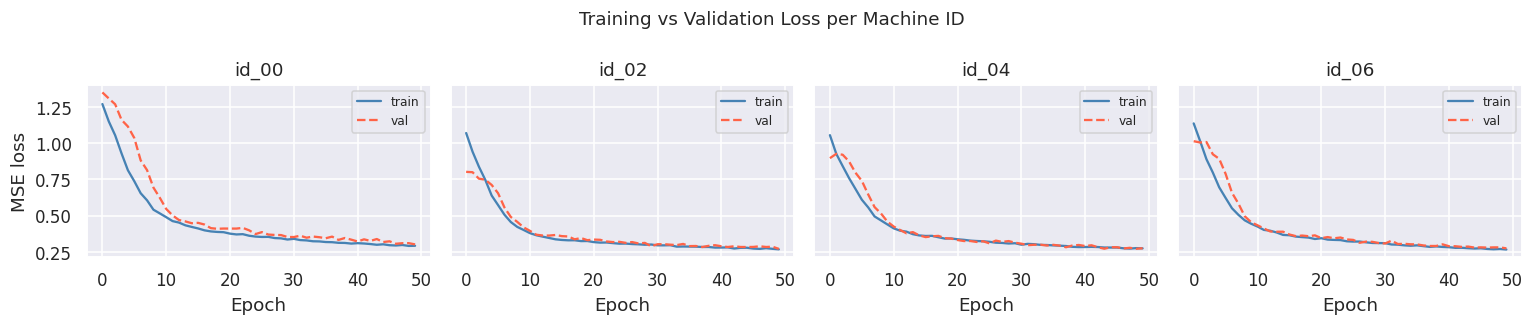

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
fig.suptitle('Training vs Validation Loss per Machine ID', fontsize=12)

for ax, machine_id in zip(axes, MACHINE_IDS):
    h = histories[machine_id]
    ax.plot(h['train'], label='train', color='steelblue')
    ax.plot(h['val'],   label='val',   color='tomato', linestyle='--')
    ax.set_title(machine_id)
    ax.set_xlabel('Epoch')
    if ax is axes[0]:
        ax.set_ylabel('MSE loss')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7 — Anomaly scoring

For each clip in the test set we:
1. Extract all frame sequences from its log-mel spectrogram
2. Pass every frame through the autoencoder
3. Compute MSE between each input frame and its reconstruction
4. Average over all frames → **one anomaly score per clip**

Higher score = more anomalous.

In [9]:
@torch.no_grad()
def score_clip(path, model, norm_mean, norm_std):
    """Return the mean per-frame reconstruction error for one audio clip."""
    frames = spectrogram_to_frames(wav_to_logmel(path))
    frames = (frames - norm_mean) / norm_std
    x = torch.from_numpy(frames).to(DEVICE)
    recon = model(x)
    return (x - recon).pow(2).mean(dim=1).mean().item()


print('Scoring test + validation files...')
results = []

for machine_id in MACHINE_IDS:
    model = models[machine_id]
    # Evaluate on val-normal + all abnormal for this ID
    eval_df = manifest[
        (manifest['machine_id'] == machine_id) &
        (manifest['split'].isin(['val', 'test']))
    ]
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=machine_id):
        score = score_clip(row['path'], model, NORM_MEAN, NORM_STD)
        results.append({
            'machine_id': machine_id,
            'label':      row['label'],
            'is_anomaly': row['is_anomaly'],
            'score':      score,
        })

results_df = pd.DataFrame(results)
print('Done.')

Scoring test + validation files...


id_00:   0%|          | 0/509 [00:00<?, ?it/s]

id_02:   0%|          | 0/461 [00:00<?, ?it/s]

id_04:   0%|          | 0/452 [00:00<?, ?it/s]

id_06:   0%|          | 0/463 [00:00<?, ?it/s]

Done.


## 8 — Evaluation

### 8.1 — AUC-ROC per machine ID

AUC-ROC measures how well the anomaly score **ranks** anomalies above normals.  
- AUC = 1.0 → perfect separation  
- AUC = 0.5 → the score is no better than random  

The DCASE 2020 Task 2 paper reports AUCs in the range 0.65–0.88 for fans at −6 dB using this method.

In [10]:
auc_scores = {}
for machine_id in MACHINE_IDS:
    sub = results_df[results_df['machine_id'] == machine_id]
    auc = roc_auc_score(sub['is_anomaly'], sub['score'])
    auc_scores[machine_id] = auc
    print(f'{machine_id}  AUC-ROC: {auc:.4f}')

mean_auc = np.mean(list(auc_scores.values()))
print(f'\nMean AUC-ROC: {mean_auc:.4f}')

id_00  AUC-ROC: 0.5003
id_02  AUC-ROC: 0.6269
id_04  AUC-ROC: 0.5158
id_06  AUC-ROC: 0.7881

Mean AUC-ROC: 0.6078


### 8.2 — ROC curves

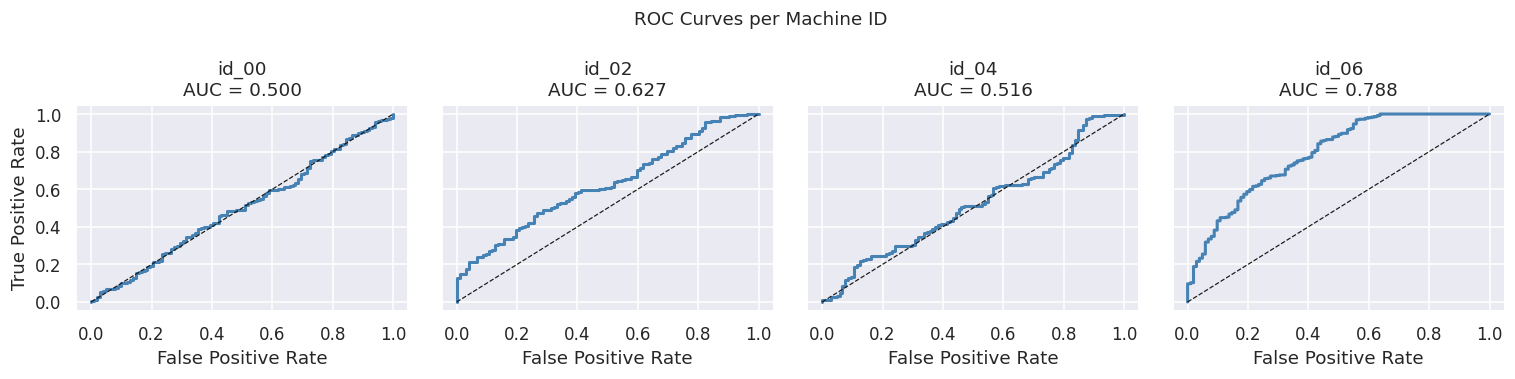

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
fig.suptitle('ROC Curves per Machine ID', fontsize=12)

for ax, machine_id in zip(axes, MACHINE_IDS):
    sub = results_df[results_df['machine_id'] == machine_id]
    fpr, tpr, _ = roc_curve(sub['is_anomaly'], sub['score'])
    auc = auc_scores[machine_id]
    ax.plot(fpr, tpr, color='steelblue', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(f'{machine_id}\nAUC = {auc:.3f}')
    ax.set_xlabel('False Positive Rate')
    if ax is axes[0]:
        ax.set_ylabel('True Positive Rate')

plt.tight_layout()
plt.show()

### 8.3 — Score distributions

Overlapping distributions mean the threshold will always misclassify some samples.  
Well-separated distributions correspond to high AUC.  
This view also reveals whether anomalies have consistently **higher** scores (good) or mixed (bad — model failed to learn the normal manifold).

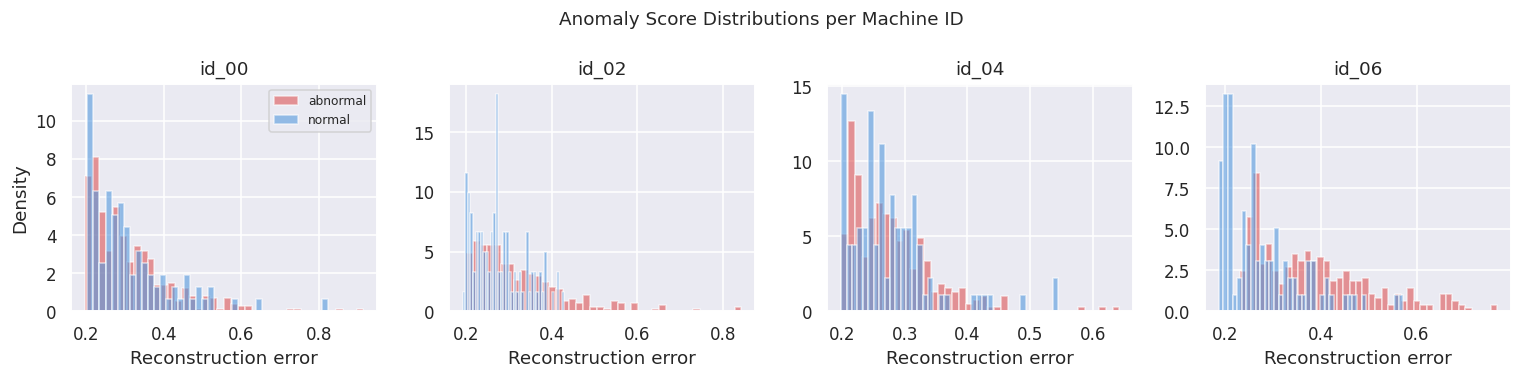

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
fig.suptitle('Anomaly Score Distributions per Machine ID', fontsize=12)

colors = {'normal': '#5599dd', 'abnormal': '#dd5555'}

for ax, machine_id in zip(axes, MACHINE_IDS):
    sub = results_df[results_df['machine_id'] == machine_id]
    for label, grp in sub.groupby('label'):
        ax.hist(grp['score'], bins=40, alpha=0.6,
                color=colors[label], label=label, density=True)
    ax.set_title(machine_id)
    ax.set_xlabel('Reconstruction error')
    if ax is axes[0]:
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9 — Summary & discussion

### Results table

In [13]:
summary = pd.DataFrame({
    'Machine ID': MACHINE_IDS,
    'AUC-ROC':    [round(auc_scores[m], 4) for m in MACHINE_IDS],
    'Train files': [len(manifest[(manifest['machine_id']==m) & (manifest['split']=='train')]) for m in MACHINE_IDS],
    'Test normal': [len(manifest[(manifest['machine_id']==m) & (manifest['split']=='val')])   for m in MACHINE_IDS],
    'Test abnormal':[len(manifest[(manifest['machine_id']==m) & (manifest['split']=='test')]) for m in MACHINE_IDS],
}).set_index('Machine ID')

summary.loc['Mean'] = summary.mean()
summary

,AUC-ROC,Train files,Test normal,Test abnormal
Machine ID,,,,
id_00,0.500300,909.00,102.0,407.00
id_02,0.626900,914.00,102.0,359.00
id_04,0.515800,929.00,104.0,348.00
id_06,0.788100,913.00,102.0,361.00
Mean,0.607775,916.25,102.5,368.75


### What limits this baseline?

| Limitation | Potential fix |
|---|---|
| Frame sequences are short (160 ms) — no long-range temporal context | Increase `N_FRAMES`, or use an LSTM/Transformer encoder |
| Fully-connected architecture ignores 2D structure of the spectrogram | Replace with a convolutional autoencoder |
| Single channel used | Average all 8 channels (beamforming) before extracting features |
| Normalisation stats computed on a subset of training files | Use all training files for a more stable estimate |
| No data augmentation | SpecAugment (time/frequency masking) on normal clips regularises the model |

### Next notebooks

- **`cnn_autoencoder.ipynb`** — replace the MLP with a 2-D convolutional autoencoder operating directly on mel spectrograms  
- **`selfsupervised.ipynb`** — contrastive learning or masked-prediction approaches that learn richer representations without reconstruction